In [47]:
import torch
import torchvision
import matplotlib


In [48]:
import os
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

In [49]:
#Exploring the data

data_path = Path("../raw_data/Flowers/train")

classes = [d.name for d in data_path.iterdir() if d.is_dir()]
print("Classes found:", classes)
print("Total classes:", len(classes))

Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total classes: 5


In [50]:
for class_name in classes:
    class_path = data_path / class_name
    images = list(class_path.glob("*.jpg"))
    print(f"{class_name}: {len(images)} images")

daisy: 764 images
dandelion: 1052 images
rose: 784 images
sunflower: 733 images
tulip: 984 images


In [51]:
#dataset class

class FlowerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        self.classes = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        
        for label, class_name in enumerate(self.classes):
            class_folder = self.root_dir / class_name
            for img_path in class_folder.glob("*.jpg"):
                self.image_paths.append(img_path)
                self.labels.append(label)
                
        print(f"Found {len(self.image_paths)} images in {len(self.classes)} classes")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [52]:
#creating the dataset

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = FlowerDataset(root_dir="../raw_data/flowers/train", transform=transform)
print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Found 4317 images in 5 classes
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images: 4317


In [53]:
#Testing the single data image

image, label = dataset[0]
print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label number:", label)
print("Label name:", dataset.classes[label])

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 128, 128])
Label number: 0
Label name: daisy


In [54]:
# creating Dataloaders

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

print("Total batches:", len(dataloader))


Total batches: 135


In [55]:
#Test batch 

images, labels = next(iter(dataloader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Labels in this batch:", labels)

Batch images shape: torch.Size([32, 3, 128, 128])
Batch labels shape: torch.Size([32])
Labels in this batch: tensor([4, 0, 0, 2, 4, 2, 0, 1, 2, 0, 3, 3, 2, 1, 1, 4, 1, 1, 0, 0, 3, 0, 2, 4,
        0, 3, 1, 1, 4, 1, 3, 1])


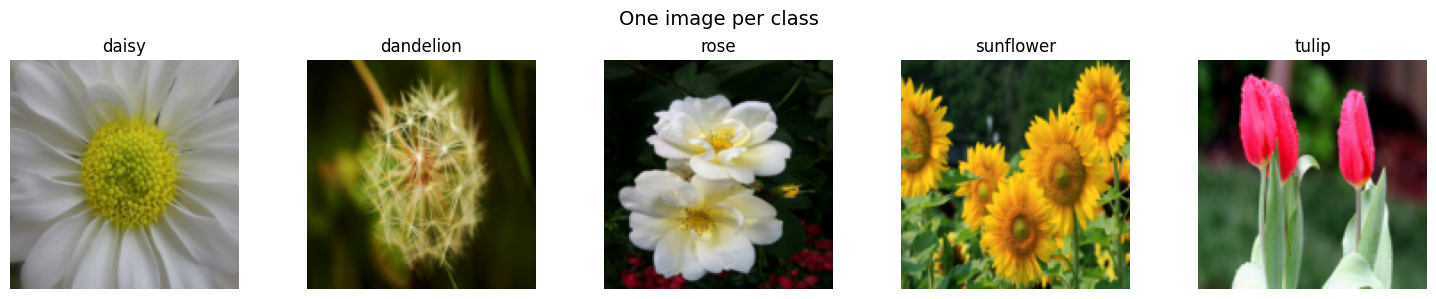

In [56]:
#Visualize


fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, class_name in enumerate(dataset.classes):
    # find first image of each class
    idx = dataset.labels.index(i)
    image, label = dataset[idx]
    
    # convert tensor back to displayable format
    img = image.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.suptitle("One image per class", fontsize=14)
plt.tight_layout()
plt.show()

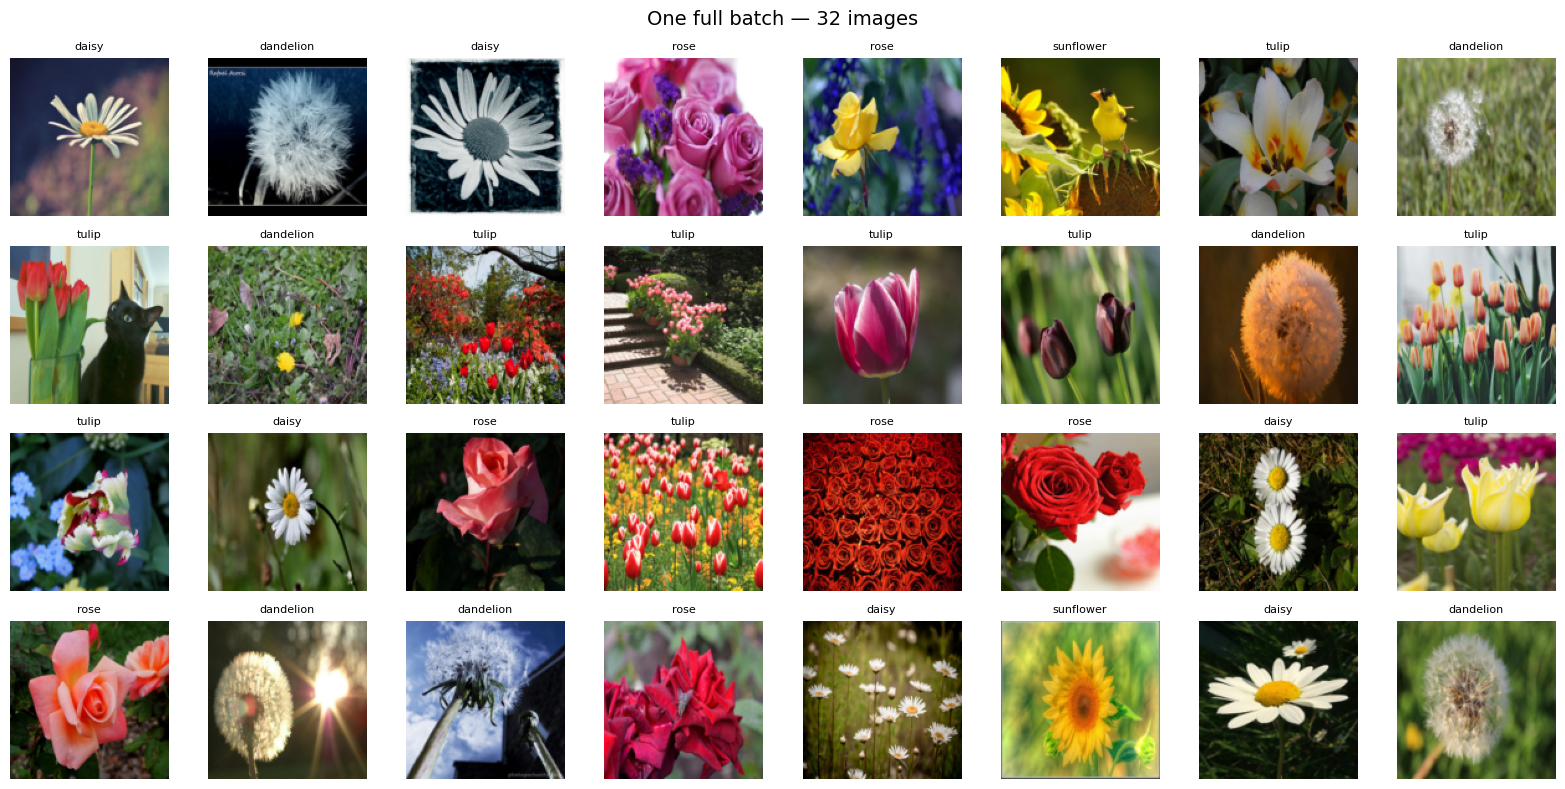

In [57]:
#Visualize full batch

images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(32):
    img = images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[labels[i]], fontsize=8)
    axes[i].axis("off")

plt.suptitle("One full batch — 32 images", fontsize=14)
plt.tight_layout()
plt.show()